# 10 - Walk-forward CV (LightGBM)

Danh gia do **on dinh theo thoi gian** cua LightGBM bang **walk-forward CV** +
**embargo**, va chon **nguong** tren VAL. Test (`step > 631`) **van niem phong** toi nb12.

Metric chinh: **PR-AUC**. Ta cung xem ROC-AUC, Brier, confusion matrix @FPR=1%, va
precision@k / recall@k (ngan sach dieu tra).


## Setup


In [1]:
# === Setup deps (chay LOCAL: Jupyter / VS Code) ==========================
# Chay 1 lan. Hoac cai san trong terminal cua moi truong (venv/conda):
#   pip install duckdb pandas numpy scikit-learn matplotlib
%pip install duckdb pandas numpy scikit-learn matplotlib mlflow lightgbm
print("deps ready")

Note: you may need to restart the kernel to use updated packages.
deps ready


C:\workspace\pit-fintech\.venv\Scripts\python.exe: No module named pip


In [2]:
# === Import data (chay LOCAL): tro thang toi file PaySim CSV tren may =====
# Khong mount Drive, khong upload - chi tro toi file CSV co san tren o cung.
from pathlib import Path

# <<< SUA duong dan CSV cho dung may ban (raw-string r"..." tren Windows) >>>
PAYSIM_CSV = r"C:\workspace\pit-fintech\data\raw\PS_20174392719_1491204439457_log.csv"

# Cache dat canh notebook -> GIU LAI giua cac lan chay (nb09 build, nb10..05 nap lai nhanh).
CACHE_DIR = "_cache"
Path(CACHE_DIR).mkdir(parents=True, exist_ok=True)

# Fallback: tu do file .csv cung thu muc neu duong dan tren sai.
if not Path(PAYSIM_CSV).exists():
    par = Path(PAYSIM_CSV).parent
    hits = sorted(par.glob("*.csv")) if par.exists() else []
    if hits:
        PAYSIM_CSV = str(hits[0])
        print("Da tu do thay CSV:", PAYSIM_CSV)
    else:
        print("!! Chua thay CSV. Hay sua PAYSIM_CSV cho dung.")

print("PAYSIM_CSV =", PAYSIM_CSV, "| exists:", Path(PAYSIM_CSV).exists())

PAYSIM_CSV = C:\workspace\pit-fintech\data\raw\PS_20174392719_1491204439457_log.csv | exists: True


In [3]:
# === PIT-safe feature module (self-contained, self-contained PIT-safe notebook contract) ==
# Xay dung dac trung POINT-IN-TIME CORRECT truc tiep tren raw CSV bang DuckDB:
# voi moi giao dich "cutoff", chi doc cac su kien TRUOC do cua CUNG mot nguoi
# nhan (nameDest) trong cac cua so 1h / 24h / 168h. Khong doc so du tai khoan,
# khong doc nhan, khong doc tuong lai -> khong ro ri (leakage).
#
# Pham vi cham diem: type in (CASH_OUT, TRANSFER) va nguoi nhan la KHACH HANG
# (nameDest bat dau bang 'C'). Day dung la noi gian lan PaySim ton tai.
import duckdb
import numpy as np
import pandas as pd

MAX_WINDOW = 168  # cua so lich su rong nhat (gio)

# 2 dac trung request-time + 8 dac trung lich su PIT = 10 (bo v3, ADR-011).
STATIC_FEATURES = ["current_amount", "transaction_type_transfer"]
HISTORY_FEATURES = [
    "pit_prior_count_1h",
    "pit_prior_amount_1h",
    "pit_prior_count_24h",
    "pit_prior_amount_24h",
    "pit_prior_amount_168h",
    "pit_distinct_senders_24h",
    "pit_distinct_senders_168h",
    "pit_steps_since_last_event",
]
ALL_FEATURES = STATIC_FEATURES + HISTORY_FEATURES

# Bo dac trung "deployable" mac dinh (fallback neu chua chay ablation o nb09).
DEPLOYABLE_CORE = [
    "current_amount",
    "transaction_type_transfer",
    "pit_prior_amount_1h",
    "pit_prior_amount_24h",
    "pit_prior_amount_168h",
    "pit_prior_count_1h",
    "pit_prior_count_24h",
]

# 4 cot so du + nhan: TUYET DOI khong duoc lam dac trung dau vao (leakage/label).
FORBIDDEN_INPUTS = [
    "isFraud",
    "isFlaggedFraud",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
]

# Ranh gioi split theo thoi gian (step). Fit qua khu -> chon nguong tren val ->
# bao cao 1 lan tren test. Split ngau nhien se ro ri tuong lai.
TRAIN_MAX_STEP = 520
VAL_MAX_STEP = 631

# Walk-forward CV: train step <= cut - embargo, test cua so (cut, cut + width].
DEFAULT_CUTS = (360, 420, 480, 540)
DEFAULT_TEST_WIDTH = 55

SEED = 20_260_727

# MAX_STEPS: dat 1 so nho (vd 200) de chay thu nhanh; None = dung toan bo du lieu.
MAX_STEPS = None


def connect_paysim(csv_path, max_steps=None):
    """Doc CSV bang pandas (bo qua dong hong) roi register vao DuckDB lam view `paysim`.

    Doc bang pandas chiu loi tot hon read_csv_auto cua DuckDB (dong hong -> skip thay vi crash).
    source_row_number = thu tu dong trong file, dung lam tie-break cho PIT.
    """
    df = pd.read_csv(csv_path, on_bad_lines="skip")
    df.insert(0, "source_row_number", range(1, len(df) + 1))
    if max_steps:
        df = df[df["step"] <= int(max_steps)].reset_index(drop=True)
    con = duckdb.connect()
    con.register("paysim", df)
    return con


def pit_feature_sql(relation="paysim"):
    """SQL sinh 1 vector dac trung PIT cho moi cutoff trong pham vi cham diem.

    Self-join theo nameDest, chi lay su kien co s.step trong [c.step-168, c.step-1]
    (chan tren la c.step-1 -> loai het su kien cung step). Moi cua so con lai duoc
    thu hep them bang FILTER. Tien duoc cong o DECIMAL(18,2) de tong on dinh.
    """
    return f"""
    SELECT
        c.nameDest AS destination_entity_id,
        c.source_row_number,
        c.step,
        CAST(c.amount AS DOUBLE) AS current_amount,
        (CASE WHEN c.type = 'TRANSFER' THEN 1.0 ELSE 0.0 END) AS transaction_type_transfer,
        (count(s.source_row_number)
            FILTER (WHERE s.step >= c.step - 1   AND s.step <= c.step - 1))::BIGINT
            AS pit_prior_count_1h,
        coalesce(sum(CAST(s.amount AS DECIMAL(18,2)))
            FILTER (WHERE s.step >= c.step - 1   AND s.step <= c.step - 1), 0.0)::DOUBLE
            AS pit_prior_amount_1h,
        (count(s.source_row_number)
            FILTER (WHERE s.step >= c.step - 24  AND s.step <= c.step - 1))::BIGINT
            AS pit_prior_count_24h,
        coalesce(sum(CAST(s.amount AS DECIMAL(18,2)))
            FILTER (WHERE s.step >= c.step - 24  AND s.step <= c.step - 1), 0.0)::DOUBLE
            AS pit_prior_amount_24h,
        coalesce(sum(CAST(s.amount AS DECIMAL(18,2)))
            FILTER (WHERE s.step >= c.step - 168 AND s.step <= c.step - 1), 0.0)::DOUBLE
            AS pit_prior_amount_168h,
        (count(DISTINCT s.nameOrig)
            FILTER (WHERE s.step >= c.step - 24  AND s.step <= c.step - 1))::BIGINT
            AS pit_distinct_senders_24h,
        (count(DISTINCT s.nameOrig)
            FILTER (WHERE s.step >= c.step - 168 AND s.step <= c.step - 1))::BIGINT
            AS pit_distinct_senders_168h,
        coalesce(
            c.step - (max(s.step) FILTER (WHERE s.step >= c.step - 168 AND s.step <= c.step - 1)),
            999
        )::BIGINT AS pit_steps_since_last_event,
        c.isFraud
    FROM {relation} AS c
    LEFT JOIN {relation} AS s
        ON s.nameDest = c.nameDest
        AND s.step >= c.step - {MAX_WINDOW}
        AND s.step <= c.step - 1
    WHERE c.type IN ('CASH_OUT', 'TRANSFER')
      AND starts_with(c.nameDest, 'C')
    GROUP BY c.nameDest, c.source_row_number, c.step, c.type, c.amount, c.isFraud
    ORDER BY c.step, c.source_row_number
    """


def build_modeling_frame(csv_path=None, max_steps=None, cache_path=None, rebuild=False):
    """Tra ve DataFrame: 10 dac trung + step + isFraud (+ id). Cache ra parquet neu co."""
    if cache_path and (not rebuild) and Path(cache_path).exists():
        print("Nap frame tu cache:", cache_path)
        frame = pd.read_parquet(cache_path)
    else:
        con = connect_paysim(csv_path, max_steps=max_steps)
        print("Dang dung lai dac trung PIT (self-join tren raw CSV)... co the mat vai phut.")
        frame = con.execute(pit_feature_sql("paysim")).df()
        con.close()
        if cache_path:
            frame.to_parquet(cache_path, index=False)
            print("Da cache frame ->", cache_path)
    frame[ALL_FEATURES] = frame[ALL_FEATURES].astype("float64")
    frame["isFraud"] = frame["isFraud"].astype(int)
    return frame


def three_way_temporal_split(frame, train_max=TRAIN_MAX_STEP, val_max=VAL_MAX_STEP):
    """train step<=train_max / val (train_max, val_max] / test step>val_max."""
    return {
        "train": frame[frame["step"] <= train_max],
        "val": frame[(frame["step"] > train_max) & (frame["step"] <= val_max)],
        "test": frame[frame["step"] > val_max],
    }


def walk_forward_folds(frame, cuts=DEFAULT_CUTS, test_width=DEFAULT_TEST_WIDTH, embargo=0):
    """Danh sach fold walk-forward theo step; moi phan tu la (cut, train_df, test_df)."""
    folds = []
    for cut in cuts:
        train = frame[frame["step"] <= cut - embargo]
        test = frame[(frame["step"] > cut) & (frame["step"] <= cut + test_width)]
        usable = len(train) > 0 and len(test) > 0 and test["isFraud"].nunique() == 2
        folds.append(
            {"cut": cut, "embargo": embargo, "train": train, "test": test, "usable": usable}
        )
    return folds


print("Feature module loaded. ALL_FEATURES =", ALL_FEATURES)

Feature module loaded. ALL_FEATURES = ['current_amount', 'transaction_type_transfer', 'pit_prior_count_1h', 'pit_prior_amount_1h', 'pit_prior_count_24h', 'pit_prior_amount_24h', 'pit_prior_amount_168h', 'pit_distinct_senders_24h', 'pit_distinct_senders_168h', 'pit_steps_since_last_event']


In [4]:
# === Doc/ghi bo dac trung da chot o nb09 (handoff giua cac notebook) ======
import json

SELECTED_FEATURES_JSON = str(Path(CACHE_DIR) / "selected_features.json")


def save_selected_features(features, source="nb09-ablation"):
    Path(SELECTED_FEATURES_JSON).write_text(
        json.dumps({"features": list(features), "source": source}, indent=2), encoding="utf-8"
    )
    print("Da ghi selected features ->", SELECTED_FEATURES_JSON)


def load_selected_features(fallback=None):
    chosen = list(fallback) if fallback is not None else list(DEPLOYABLE_CORE)
    if Path(SELECTED_FEATURES_JSON).exists():
        got = json.loads(Path(SELECTED_FEATURES_JSON).read_text(encoding="utf-8")).get("features")
        if got:
            chosen = list(got)
    return chosen

In [5]:
# === LightGBM: 1 factory dung chung cho moi notebook =====================
import lightgbm as lgb


def make_lgbm(params=None, seed=SEED):
    base = dict(
        n_estimators=100,  # it cay -> chay thu nhanh; tang lai khi chay final
        learning_rate=0.1,
        num_leaves=31,  # do phuc tap moi cay
        max_depth=-1,  # -1 = khong gioi han (num_leaves da khong che)
        min_child_samples=50,  # la to hon -> bot overfit tren fraud hiem
        subsample=0.7,  # bagging_fraction: moi vong lay 70% dong
        subsample_freq=1,  # bat subsample (mac dinh 0 = tat)
        colsample_bytree=0.8,  # feature_fraction
        class_weight="balanced",  # bu lech lop cuc doan cua fraud
        n_jobs=-1,
        random_state=seed,
        verbosity=-1,
    )
    if params:
        base.update(params)
    return lgb.LGBMClassifier(**base)

In [6]:
FRAME_CACHE = str(Path(CACHE_DIR) / "modeling_frame.parquet")
frame = build_modeling_frame(PAYSIM_CSV, max_steps=MAX_STEPS, cache_path=FRAME_CACHE, rebuild=False)
FEATURES = load_selected_features(DEPLOYABLE_CORE)
print("FEATURES (", len(FEATURES), "):", FEATURES)

Nap frame tu cache: _cache\modeling_frame.parquet
FEATURES ( 10 ): ['current_amount', 'transaction_type_transfer', 'pit_prior_count_1h', 'pit_prior_amount_1h', 'pit_prior_count_24h', 'pit_prior_amount_24h', 'pit_prior_amount_168h', 'pit_distinct_senders_24h', 'pit_distinct_senders_168h', 'pit_steps_since_last_event']


## Part A - 3-way split & train mot LightGBM tham chieu


In [7]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
)

splits = three_way_temporal_split(frame)
for k, v in splits.items():
    print(
        f"{k:5s}: rows={len(v):>8d}  frauds={int(v['isFraud'].sum()):>5d}  "
        f"rate={v['isFraud'].mean():.5f}"
    )

model = make_lgbm()
model.fit(splits["train"][FEATURES], splits["train"]["isFraud"])
yval = splits["val"]["isFraud"].to_numpy()
pval = model.predict_proba(splits["val"][FEATURES])[:, 1]

train: rows= 2653729  frauds= 5781  rate=0.00218
val  : rows=   78701  frauds= 1180  rate=0.01499
test : rows=   37979  frauds= 1252  rate=0.03297


### Bo metric KHONG nguong (tren VAL)


In [8]:
prevalence = float(yval.mean())
free = pd.DataFrame(
    [
        {
            "pr_auc": round(average_precision_score(yval, pval), 6),
            "roc_auc": round(roc_auc_score(yval, pval), 6),
            "brier": round(brier_score_loss(yval, pval), 6),
            "prevalence": round(prevalence, 6),
        }
    ]
)
display(free)
print(
    "PR-AUC / prevalence (lift so voi doan ngau nhien) =",
    round(free.loc[0, "pr_auc"] / prevalence, 2),
    "x",
)

,pr_auc,roc_auc,brier,prevalence
0,0.287178,0.847133,0.224009,0.014993


PR-AUC / prevalence (lift so voi doan ngau nhien) = 19.15 x


### Metric CO nguong (chon nguong @ FPR=1% tren VAL)


In [9]:
fpr, tpr, thr = roc_curve(yval, pval)
idx = int(np.argmin(np.abs(fpr - 0.01)))
chosen_thr = float(thr[idx])
pred = (pval >= chosen_thr).astype(int)
tn, fp, fn, tp = confusion_matrix(yval, pred).ravel()
prec = tp / (tp + fp) if (tp + fp) else 0.0
rec = tp / (tp + fn) if (tp + fn) else 0.0
f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
display(
    pd.DataFrame(
        [
            {
                "threshold@FPR=1%": round(chosen_thr, 4),
                "TP": tp,
                "FP": fp,
                "FN": fn,
                "TN": tn,
                "precision": round(prec, 4),
                "recall": round(rec, 4),
                "f1": round(f1, 4),
            }
        ]
    )
)

,threshold@FPR=1%,TP,FP,FN,TN,precision,recall,f1
0,0.9642,347,765,833,76756,0.3121,0.2941,0.3028


### Duong PR & ROC + ngan sach precision@k/recall@k (VAL)


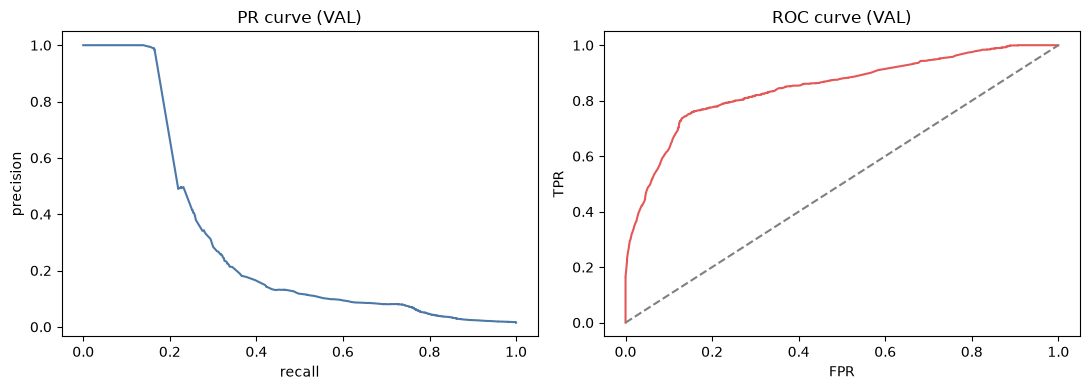

,k,flagged,precision@k,recall@k
0,0.001,78,1.0000,0.0661
1,0.005,393,0.5852,0.1949
2,0.010,787,0.3888,0.2593


In [10]:
import matplotlib.pyplot as plt

prec_c, rec_c, _ = precision_recall_curve(yval, pval)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(rec_c, prec_c, color="#4C78A8")
ax[0].set_title("PR curve (VAL)")
ax[0].set_xlabel("recall")
ax[0].set_ylabel("precision")
ax[1].plot(fpr, tpr, color="#E45756")
ax[1].plot([0, 1], [0, 1], "--", color="gray")
ax[1].set_title("ROC curve (VAL)")
ax[1].set_xlabel("FPR")
ax[1].set_ylabel("TPR")
plt.tight_layout()
plt.show()


def pr_at_k(y, p, k):
    n = max(1, int(len(p) * k))
    top = np.argsort(p)[::-1][:n]
    tp = int(y[top].sum())
    total_pos = int(y.sum())
    return {
        "k": k,
        "flagged": n,
        "precision@k": round(tp / n, 4),
        "recall@k": round(tp / total_pos, 4) if total_pos else 0.0,
    }


display(pd.DataFrame([pr_at_k(yval, pval, k) for k in (0.001, 0.005, 0.01)]))

## Part B - Walk-forward CV + embargo

Train qua khu, test cua so thoi gian ke tiep. Lam voi vai muc embargo (0 / 24 / 168 gio)
de xem do dao dong PR-AUC -> muc **khong chac chan** ma 1 split don khong the hien duoc.


In [11]:
def run_walkforward(frame, features, embargos=(0, 24, 168)):
    rows = []
    for e in embargos:
        for fold in walk_forward_folds(frame, embargo=e):
            if not fold["usable"]:
                continue
            m = make_lgbm()
            m.fit(fold["train"][features], fold["train"]["isFraud"])
            yt = fold["test"]["isFraud"].to_numpy()
            pt = m.predict_proba(fold["test"][features])[:, 1]
            rows.append(
                {
                    "embargo": e,
                    "cut": fold["cut"],
                    "test_rows": len(yt),
                    "test_frauds": int(yt.sum()),
                    "pr_auc": round(average_precision_score(yt, pt), 6),
                }
            )
    return pd.DataFrame(rows)


folds_result = run_walkforward(frame, FEATURES)
display(folds_result)
summary = folds_result.groupby("embargo")["pr_auc"].agg(["mean", "std", "min", "max"]).round(6)
display(summary)

,embargo,cut,test_rows,test_frauds,pr_auc
0,0,360,351191,682,0.245762
1,0,420,15471,574,0.613849
2,0,480,32018,592,0.352324
3,0,540,49688,580,0.287001
4,24,360,351191,682,0.237603
5,24,420,15471,574,0.615523
6,24,480,32018,592,0.334235
7,24,540,49688,580,0.287197
8,168,360,351191,682,0.211998
9,168,420,15471,574,0.602901


,mean,std,min,max
embargo,,,,
0,0.374734,0.165337,0.245762,0.613849
24,0.368640,0.169252,0.237603,0.615523
168,0.351622,0.175239,0.211998,0.602901


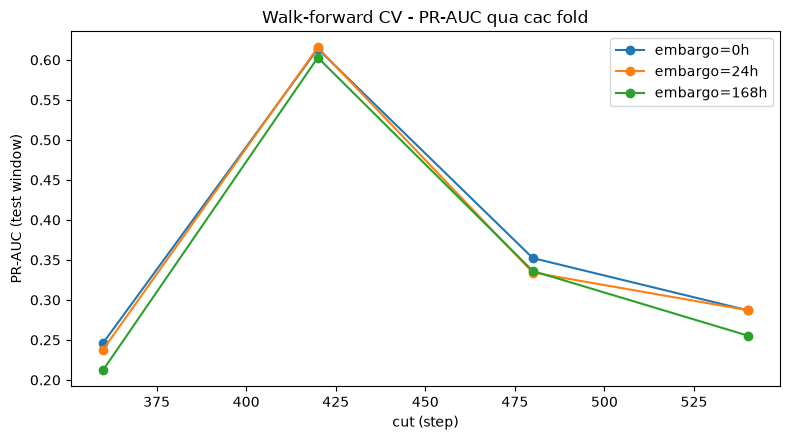

In [12]:
if len(folds_result):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for e, grp in folds_result.groupby("embargo"):
        ax.plot(grp["cut"], grp["pr_auc"], marker="o", label=f"embargo={e}h")
    ax.set_xlabel("cut (step)")
    ax.set_ylabel("PR-AUC (test window)")
    ax.set_title("Walk-forward CV - PR-AUC qua cac fold")
    ax.legend()
    plt.tight_layout()
    plt.show()

## Part C - Phu thuoc trang-entity: recipient CU (warm) vs MOI (cold)

Chia VAL theo `pit_distinct_senders_168h > 0` (co lich su) hay `= 0` (cold-start) de xem model
manh/yeu o dau - rat quan trong voi bai toan gian lan (nhieu victim la tai khoan moi).


In [13]:
warm_mask = splits["val"]["pit_distinct_senders_168h"].to_numpy() > 0
rows = []
for label, mask in [("warm (co lich su)", warm_mask), ("cold (moi)", ~warm_mask)]:
    if mask.sum() == 0 or yval[mask].sum() == 0:
        continue
    rows.append(
        {
            "cohort": label,
            "rows": int(mask.sum()),
            "frauds": int(yval[mask].sum()),
            "pr_auc": round(average_precision_score(yval[mask], pval[mask]), 6),
        }
    )
display(pd.DataFrame(rows))

,cohort,rows,frauds,pr_auc
0,warm (co lich su),32238,186,0.404187
1,cold (moi),46463,994,0.266670


## Ket luan & ban giao sang nb11

- PR-AUC trung binh & do dao dong qua cac fold cho biet model on dinh toi dau theo thoi gian.
- Embargo lon hon = danh gia bao thu hon (cat bo phu thuoc gan-thoi-gian).
- nb11: **tune sieu tham so** cua LightGBM tren dung cac fold nay + chon nguong.


## MLflow logging (Data-Centric AI)

Ba cell cuoi (chay sau cung, sau khi da chay het notebook): **schema chuan** (giong het moi notebook) + **cell log** rieng cua notebook nay. Log truc tiep len MLflow chung `http://100.116.36.6:5000`; khong fallback sang local.


In [ ]:
# ============================================================================
# MLflow logging schema - Data-Centric AI (Andrew Ng). CELL CHUAN, dat O CUOI
# notebook. Copy-paste GIONG HET vao ca 5 notebook 08..12 (track LightGBM).
# Log truc tiep len MLflow chung (http://100.116.36.6:5000).
# Neu server khong reachable, dung lai voi loi ro rang; khong ghi nham sang local.
# ============================================================================
import hashlib
import json as _json
import os
import socket
from datetime import datetime, timezone, UTC
from pathlib import Path as _Path

MLFLOW_TRACKING_URI = os.environ.get("MLFLOW_TRACKING_URI", "http://100.116.36.6:5000")
MLFLOW_EXPERIMENT = "paysim-fraud-lgbm-colab"  # track self-contained LightGBM notebook pipeline
REGISTRY_MODEL_NAME = "paysim-fraud-lightgbm"  # CHI notebook cuoi (12) register


def _mlflow_ready():
    try:
        import mlflow
        import mlflow.lightgbm
    except ImportError:
        print("[mlflow] chua cai (pip install mlflow) -> notebook van chay, khong log")
        return None
    uri = MLFLOW_TRACKING_URI
    # The Colab contract uses the shared MLflow server. Do not silently
    # switch to a local tracking store: that would split runs across backends.
    if uri.startswith(("http://", "https://")):
        try:
            netloc = uri.split("//", 1)[-1].split("/", 1)[0]
            host, _, port = netloc.rpartition(":")
            if not host:
                host, port = netloc, "80"
            socket.create_connection((host, int(port)), timeout=5).close()
        except (OSError, ValueError) as exc:
            raise RuntimeError(
                f"Shared MLflow server is not reachable at {uri}; "
                "set MLFLOW_TRACKING_URI to the intended remote server and retry."
            ) from exc
    mlflow.set_tracking_uri(uri)
    mlflow.set_experiment(MLFLOW_EXPERIMENT)
    print(f"[mlflow] tracking={uri} experiment={MLFLOW_EXPERIMENT}")
    return mlflow


MLFLOW = _mlflow_ready()  # None => moi helper duoi day tu no-op


def data_version(frame=None, csv_path=None):
    """Danh tinh du lieu (Data-Centric): hash prefix CSV + so dong + range step + fraud rate."""
    info = {}
    p = csv_path or globals().get("PAYSIM_CSV")
    if p and _Path(p).exists():
        h = hashlib.sha256()
        with open(p, "rb") as f:
            h.update(f.read(8 * 1024 * 1024))  # 8MB dau -> dinh danh nhanh, on dinh
        info["csv_sha8"] = h.hexdigest()[:8]
        info["csv_bytes"] = _Path(p).stat().st_size
    info["max_steps"] = str(globals().get("MAX_STEPS"))
    if frame is not None and len(frame):
        info["row_count"] = len(frame)
        info["step_min"] = int(frame["step"].min())
        info["step_max"] = int(frame["step"].max())
        info["fraud_rate"] = round(float(frame["isFraud"].mean()), 6)
    return info


def start_run(stage, params=None, extra_tags=None):
    if MLFLOW is None:
        return None
    timestamp = datetime.now(UTC).strftime("%Y%m%d-%H%M%S")
    run = MLFLOW.start_run(run_name=f"{stage}__{timestamp}")
    tags = {
        "stage": stage,
        "model_family": "lightgbm",
        "code_source": "notebook",
        "primary_metric": "pr_auc",
        "split_protocol": "temporal_70_15_15",
        "sealed_test_touched": "false",
    }
    tags.update(extra_tags or {})
    MLFLOW.set_tags(tags)
    if params:
        MLFLOW.log_params({k: v for k, v in params.items() if v is not None})
    return run


def log_metrics(metrics):
    if MLFLOW is None:
        return
    MLFLOW.log_metrics({k: float(v) for k, v in metrics.items() if v is not None})


def log_sliced_pr_auc(y_true, y_score, slices, prefix="pr_auc"):
    """slices = {ten: mask_bool}. Chi log slice co ca 2 lop de PR-AUC co nghia (Data-Centric)."""
    if MLFLOW is None:
        return
    import numpy as np
    from sklearn.metrics import average_precision_score

    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    MLFLOW.log_metric(prefix, float(average_precision_score(y_true, y_score)))
    for name, mask in slices.items():
        mask = np.asarray(mask, dtype=bool)
        if mask.sum() and 0 < int(y_true[mask].sum()) < int(mask.sum()):
            MLFLOW.log_metric(
                f"{prefix}__{name}",
                float(average_precision_score(y_true[mask], y_score[mask])),
            )


def log_json_artifact(obj, filename):
    if MLFLOW is None:
        return
    p = _Path(filename)
    p.write_text(_json.dumps(obj, indent=2, default=str), encoding="utf-8")
    MLFLOW.log_artifact(str(p))


def log_file_artifact(path):
    if MLFLOW is None or not _Path(path).exists():
        return
    MLFLOW.log_artifact(str(path))


def log_error_samples(
    frame, features, y_true, y_pred, y_score, n=300, filename="error_samples.csv"
):
    """Data-Centric error analysis: xuat cac ca sai (FN/FP) de soi lai chat luong du lieu."""
    if MLFLOW is None:
        return
    import numpy as np

    err = frame[list(features)].copy()
    for col in ("destination_entity_id", "step"):
        if col in frame:
            err[col] = frame[col].to_numpy()
    err["y_true"] = np.asarray(y_true)
    err["y_pred"] = np.asarray(y_pred)
    err["y_score"] = np.asarray(y_score)
    err = err[err["y_true"] != err["y_pred"]].sort_values("y_score", ascending=False).head(n)
    p = _Path(filename)
    err.to_csv(p, index=False)
    MLFLOW.log_artifact(str(p))
    print(f"[mlflow] error_samples: {len(err)} ca sai -> {filename}")


def log_lightgbm_model(model, input_frame, register=False, artifact_path="model"):
    """Log native LightGBM with an input/output signature and a concrete input example."""
    if MLFLOW is None:
        return None
    if input_frame is None or len(input_frame) == 0:
        raise ValueError("input_frame must contain at least one row for the MLflow model signature")
    input_example = input_frame.iloc[:5].copy().reset_index(drop=True)
    expected_features = list(getattr(model, "feature_name_", input_example.columns))
    if list(input_example.columns) != expected_features:
        raise ValueError(
            "MLflow input example columns do not match the fitted LightGBM feature order: "
            f"{list(input_example.columns)} != {expected_features}"
        )
    # The native LightGBM pyfunc flavor calls model.predict(), so infer the output schema
    # from predict() (class labels), not predict_proba() used by our custom serving boundary.
    signature = MLFLOW.models.infer_signature(input_example, model.predict(input_example))
    name = REGISTRY_MODEL_NAME if register else None
    try:
        info = MLFLOW.lightgbm.log_model(
            model,
            name=artifact_path,
            registered_model_name=name,
            signature=signature,
            input_example=input_example,
        )
    except TypeError:  # MLflow < 3 compatibility: artifact_path predates name
        info = MLFLOW.lightgbm.log_model(
            model,
            artifact_path=artifact_path,
            registered_model_name=name,
            signature=signature,
            input_example=input_example,
        )
    if register:
        model_uri = getattr(info, "model_uri", "?")
        print(
            f"[mlflow] registered '{REGISTRY_MODEL_NAME}' <- {model_uri} "
            "(signature + input_example)"
        )
    return info


def log_lgbm_evaluation(
    stage,
    model,
    y_true,
    y_pred,
    features=None,
    input_frame=None,
    y_score=None,
    threshold=0.5,
    params=None,
    extra_tags=None,
    register=False,
):
    """Log 1 danh gia LightGBM DAY DU cho MLflow (truc quan hon confusion don thuan):
    confusion tn/fp/fn/tp + precision/recall/f1/accuracy + pr_auc/roc_auc (neu co y_score)
    + threshold + feature importance (feature_importances_). register=True -> dang ky model."""
    if MLFLOW is None:
        print("[mlflow] skipped LGBM evaluation: tracking unavailable")
        return None
    import numpy as np
    from sklearn.metrics import (
        accuracy_score,
        confusion_matrix,
        f1_score,
        precision_score,
        recall_score,
    )

    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    metrics = {
        "confusion_tn": int(tn),
        "confusion_fp": int(fp),
        "confusion_fn": int(fn),
        "confusion_tp": int(tp),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
    }
    if y_score is not None and 0 < int(y_true.sum()) < len(y_true):
        from sklearn.metrics import average_precision_score, roc_auc_score

        y_score = np.asarray(y_score, dtype=float)
        metrics["pr_auc"] = average_precision_score(y_true, y_score)
        metrics["roc_auc"] = roc_auc_score(y_true, y_score)
    gain = {}
    imp = getattr(model, "feature_importances_", None)
    if imp is not None and features is not None and len(features) == len(imp):
        gain = {str(f): float(g) for f, g in zip(features, imp, strict=True)}
    run_params = {
        "threshold": float(threshold),
        "n_rows_evaluated": len(y_true),
        "n_features": int(getattr(model, "n_features_in_", len(features or []))),
        "lgbm_n_estimators": int(model.get_params().get("n_estimators", 0)),
        "lgbm_learning_rate": model.get_params().get("learning_rate"),
        "lgbm_num_leaves": model.get_params().get("num_leaves"),
        "lgbm_max_depth": model.get_params().get("max_depth"),
        "lgbm_min_child_samples": model.get_params().get("min_child_samples"),
        "lgbm_subsample": model.get_params().get("subsample"),
        "lgbm_colsample_bytree": model.get_params().get("colsample_bytree"),
        "lgbm_random_state": model.get_params().get("random_state"),
    }
    run_params.update(params or {})
    tags = {
        "stage": stage,
        "model_family": "lightgbm",
        "metric_contract": "full_eval",
        "code_source": "notebook",
        "sealed_test_touched": "false",
    }
    tags.update(extra_tags or {})
    artifact = {
        "labels": [0, 1],
        "threshold": float(threshold),
        "matrix": [[int(tn), int(fp)], [int(fn), int(tp)]],
        "metrics": {k: float(v) for k, v in metrics.items()},
        "feature_gain": dict(sorted(gain.items(), key=lambda kv: kv[1], reverse=True)),
    }
    with MLFLOW.start_run(run_name=f"lgbm__{stage}"):
        MLFLOW.set_tags(tags)
        MLFLOW.log_params({k: v for k, v in run_params.items() if v is not None})
        MLFLOW.log_metrics({k: float(v) for k, v in metrics.items()})
        if gain:
            MLFLOW.log_metrics({f"gain__{feature}": value for feature, value in gain.items()})
        log_json_artifact(artifact, f"evaluation_{stage}.json")
        log_lightgbm_model(model, input_frame=input_frame, register=register, artifact_path="model")
        run_id = MLFLOW.active_run().info.run_id
    _msg = f"P={metrics['precision']:.3f} R={metrics['recall']:.3f} F1={metrics['f1']:.3f}"
    if "pr_auc" in metrics:
        _msg += f" PR-AUC={metrics['pr_auc']:.4f}"
    print(f"[mlflow] LGBM eval logged stage={stage} run={run_id} {_msg}")
    return {**metrics, "run_id": run_id}


def end_run():
    if MLFLOW is not None:
        MLFLOW.end_run()

In [ ]:
# --- MLflow: log LightGBM DAY DU (confusion + P/R/F1 + PR-AUC + threshold + gain) --
if MLFLOW is not None:
    log_lgbm_evaluation(
        "nb10_walkforward_val",
        model,
        yval,
        pred,
        features=FEATURES,
        input_frame=splits["val"][FEATURES],
        y_score=pval,
        threshold=round(float(chosen_thr), 6),
        params={"split": "temporal_validation"},
        extra_tags={"notebook": "10_walkforward_cv_split"},
    )